In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive/', force_remount=True)

root_dir = '/content/drive/My Drive/'
base_dir = '/content/drive/My Drive/datasets'
os.listdir(base_dir)

Mounted at /content/drive/


['Russian-Currency-Dataset']

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix




In [ ]:
path_train_cropped = base_dir + '/Russian-Currency-Dataset/train-cropped/'
path_valid_cropped = base_dir + '/Russian-Currency-Dataset/valid-cropped/'
path_test_cropped = base_dir + '/Russian-Currency-Dataset/test-cropped/'

In [ ]:
IMAGE_SIZE = 360
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 180,
    brightness_range=[0.8, 1.2],
    # width_shift_range=0.1,
    # height_shift_range=0.1,
    # fill_mode = 'constant',
    )

test_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

train_generator = train_datagen.flow_from_directory(
    path_train_cropped,
    classes = ['Нет', '5', '10', '50', '100', '200', '500', '1000', '2000', '5000'],
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    seed = 10,
    # save_to_dir = path_aug,
    # save_prefix = 'tr-1',
    # save_format = 'jpg',
    batch_size = BATCH_SIZE)

val_generator = test_datagen.flow_from_directory(
    path_valid_cropped,
    classes = ['Нет', '5', '10', '50', '100', '200', '500', '1000', '2000', '5000'],
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    seed = 3)

test_generator = test_datagen.flow_from_directory(path_test_cropped,
                                                  classes = ['Нет', '5', '10', '50', '100', '200', '500', '1000', '2000', '5000'],
                                                  target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                                  batch_size=BATCH_SIZE)

Found 8750 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.
Found 1250 images belonging to 10 classes.


In [ ]:
IMG_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)

base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                              include_top=False,
                                              weights='imagenet')

model = tf.keras.Sequential([
  base_model,
  tf.keras.layers.GlobalMaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(512),
  tf.keras.layers.Activation('relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(10, activation='softmax')
])

9406464/9406464 [==============================] - 1s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy',
              metrics = ['categorical_accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 12, 12, 1280)      2257984   
 tional)                                                         
                                                                 
 global_max_pooling2d (Glob  (None, 1280)              0         
 alMaxPooling2D)                                                 
                                                                 
 flatten (Flatten)           (None, 1280)              0         
                                                                 
 batch_normalization (Batch  (None, 1280)              5120      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                        

In [ ]:
model.save_weights(path_train_cropped + 'save/fine_tuning/save-weights-1-top-mobnet.h5')

In [ ]:
epochs = 8

history = model.fit_generator(train_generator,
                    epochs=epochs,
                    validation_data=val_generator)

<ipython-input-9-97ffc2efa49b>:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(train_generator,


Epoch 1/8
274/274 [==============================] - 8340s 30s/step - loss: 0.7889 - categorical_accuracy: 0.7554 - val_loss: 0.2058 - val_categorical_accuracy: 0.9392
Epoch 2/8
274/274 [==============================] - 1756s 6s/step - loss: 0.3402 - categorical_accuracy: 0.8880 - val_loss: 0.1272 - val_categorical_accuracy: 0.9620
Epoch 3/8
274/274 [==============================] - 1747s 6s/step - loss: 0.2676 - categorical_accuracy: 0.9115 - val_loss: 0.1098 - val_categorical_accuracy: 0.9680
Epoch 4/8
274/274 [==============================] - 1728s 6s/step - loss: 0.2337 - categorical_accuracy: 0.9208 - val_loss: 0.0963 - val_categorical_accuracy: 0.9708
Epoch 5/8
274/274 [==============================] - 1807s 7s/step - loss: 0.2118 - categorical_accuracy: 0.9258 - val_loss: 0.0748 - val_categorical_accuracy: 0.9780
Epoch 6/8
274/274 [==============================] - 1799s 7s/step - loss: 0.1971 - categorical_accuracy: 0.9331 - val_loss: 0.0571 - val_categorical_accuracy: 0.98

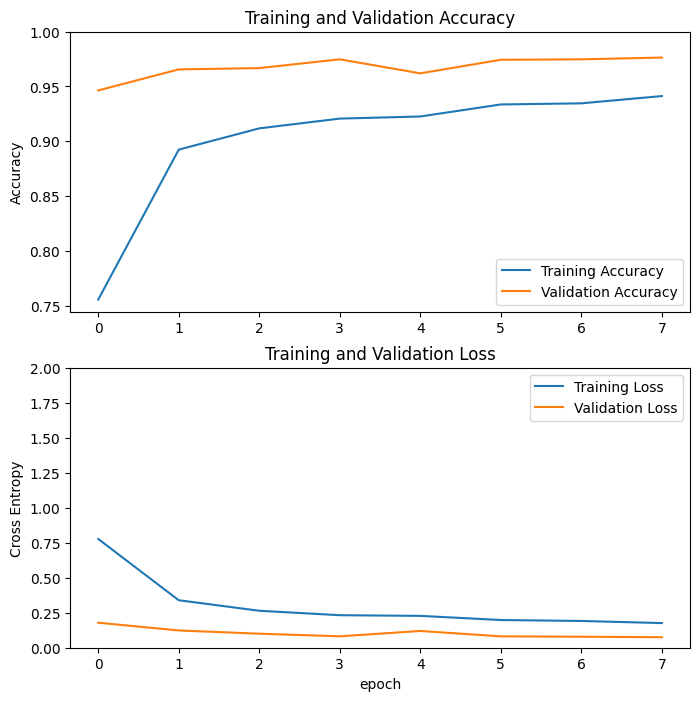

In [ ]:
acc = history.history['categorical_accuracy']
val_acc = history.history['val_categorical_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,2.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
epochs = 5

history = model.fit_generator(train_generator,
                    epochs = epochs,
                    validation_data = val_generator)

<ipython-input-11-0dc965b1a8fa>:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(train_generator,


Epoch 1/5
274/274 [==============================] - 3256s 12s/step - loss: 0.1800 - categorical_accuracy: 0.9393 - val_loss: 0.0584 - val_categorical_accuracy: 0.9840
Epoch 2/5
274/274 [==============================] - 1746s 6s/step - loss: 0.1642 - categorical_accuracy: 0.9443 - val_loss: 0.0667 - val_categorical_accuracy: 0.9796
Epoch 3/5
274/274 [==============================] - 1757s 6s/step - loss: 0.1492 - categorical_accuracy: 0.9504 - val_loss: 0.0439 - val_categorical_accuracy: 0.9876
Epoch 4/5
274/274 [==============================] - 1784s 7s/step - loss: 0.1529 - categorical_accuracy: 0.9504 - val_loss: 0.0466 - val_categorical_accuracy: 0.9856
Epoch 5/5
274/274 [==============================] - 1772s 6s/step - loss: 0.1470 - categorical_accuracy: 0.9506 - val_loss: 0.0503 - val_categorical_accuracy: 0.9828


In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-top-mobnet.h5')
epochs = 5

history = model.fit_generator(train_generator,
                    epochs = epochs,
                    validation_data = val_generator)

<ipython-input-12-14774f6625cb>:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(train_generator,


Epoch 1/5
274/274 [==============================] - 1800s 7s/step - loss: 0.1455 - categorical_accuracy: 0.9501 - val_loss: 0.0637 - val_categorical_accuracy: 0.9796
Epoch 2/5
274/274 [==============================] - 1813s 7s/step - loss: 0.1402 - categorical_accuracy: 0.9542 - val_loss: 0.0441 - val_categorical_accuracy: 0.9860
Epoch 3/5
274/274 [==============================] - 1800s 7s/step - loss: 0.1450 - categorical_accuracy: 0.9503 - val_loss: 0.0479 - val_categorical_accuracy: 0.9840
Epoch 4/5
274/274 [==============================] - 1845s 7s/step - loss: 0.1337 - categorical_accuracy: 0.9557 - val_loss: 0.0445 - val_categorical_accuracy: 0.9880
Epoch 5/5
274/274 [==============================] - 1819s 7s/step - loss: 0.1307 - categorical_accuracy: 0.9566 - val_loss: 0.0528 - val_categorical_accuracy: 0.9792


In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-3-top-mobnet.h5')
epochs = 5

history = model.fit_generator(train_generator,
                    epochs = epochs,
                    validation_data = val_generator)

<ipython-input-13-b94f5fe914b9>:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(train_generator,


Epoch 1/5
274/274 [==============================] - 1862s 7s/step - loss: 0.1146 - categorical_accuracy: 0.9632 - val_loss: 0.0475 - val_categorical_accuracy: 0.9852
Epoch 2/5
274/274 [==============================] - 1838s 7s/step - loss: 0.1238 - categorical_accuracy: 0.9605 - val_loss: 0.0407 - val_categorical_accuracy: 0.9856
Epoch 3/5
274/274 [==============================] - 1840s 7s/step - loss: 0.1147 - categorical_accuracy: 0.9617 - val_loss: 0.0475 - val_categorical_accuracy: 0.9832
Epoch 4/5
274/274 [==============================] - 1766s 6s/step - loss: 0.1139 - categorical_accuracy: 0.9610 - val_loss: 0.0572 - val_categorical_accuracy: 0.9812
Epoch 5/5
274/274 [==============================] - 1769s 6s/step - loss: 0.1193 - categorical_accuracy: 0.9598 - val_loss: 0.0310 - val_categorical_accuracy: 0.9916


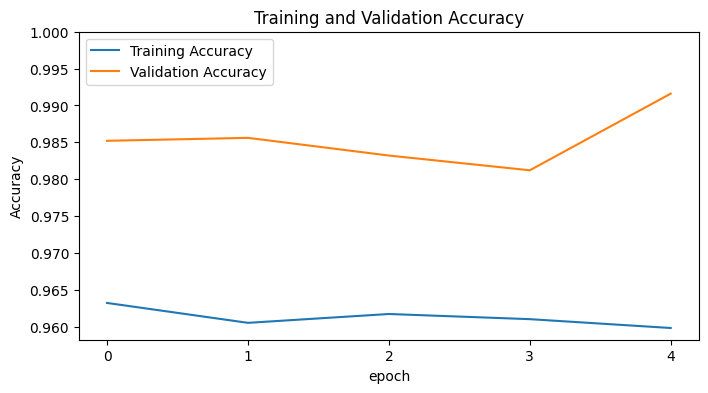

In [ ]:
#model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-4-top-mobnet.h5')

# acc = [0.9632, 0.9605, 0.9617, 0.9610, 0.9598]
# val_acc = [0.9852, 0.9856, 0.9832, 0.9812, 0.9916]
# x = [0, 1, 2, 3, 4]

acc = history.history['categorical_accuracy']
val_acc = history.history['val_categorical_accuracy']

plt.figure(figsize=(8, 4))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='upper left')
plt.ylabel('Accuracy')
plt.xticks(np.arange(min(x), max(x)+1, 1))
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')
plt.xlabel('epoch')
plt.show()

In [ ]:
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-1-top-mobnet.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-top-mobnet.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-3-top-mobnet.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-ResNet-top.h5')

epochs = 20

history_1 = model.fit_generator(train_generator,
                    epochs=epochs,
                    validation_data=val_generator)

<ipython-input-10-0936d2248d91>:8: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history_1 = model.fit_generator(train_generator,


Epoch 1/20
274/274 [==============================] - 1760s 6s/step - loss: 0.1115 - categorical_accuracy: 0.9623 - val_loss: 0.0268 - val_categorical_accuracy: 0.9912
Epoch 2/20
274/274 [==============================] - 1751s 6s/step - loss: 0.1060 - categorical_accuracy: 0.9649 - val_loss: 0.0244 - val_categorical_accuracy: 0.9932
Epoch 3/20
 25/274 [=>............................] - ETA: 22:16 - loss: 0.1003 - categorical_accuracy: 0.9675

In [ ]:
epochs = 20

history_1 = model.fit_generator(train_generator,
                    epochs=epochs,
                    validation_data=val_generator)

In [ ]:
model.save(path_train_cropped + '/save/stage-2.h5')

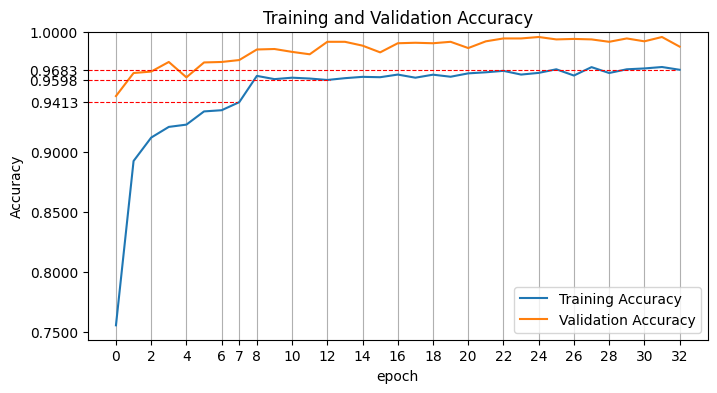

In [ ]:
# model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-1-top-mobnet.h5')
# model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-top-mobnet.h5')
# model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-3-top-mobnet.h5')
# model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-ResNet-top.h5')
# model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2.h5')
# model.save(path_train_cropped + '/save/stage-2.h5')

acc = history.history['categorical_accuracy']
val_acc = history.history['val_categorical_accuracy']


# acc = [0.7554, 0.8923, 0.9118, 0.9207, 0.9226, 0.9336, 0.9346, 0.9413]
# val_acc = [0.9464, 0.9656, 0.9668, 0.9748, 0.9620, 0.9744, 0.9748, 0.9764]
# x = [0, 1, 2, 3, 4, 5, 6, 7]
# res1 = [0.9413, 0.9413, 0.9413, 0.9413, 0.9413, 0.9413, 0.9413, 0.9413]
# res1 = [0.9413, 0.9413, 0.9413, 0.9413, 0.9413, 0.9413, 0.9413, 0.9413]

# acc = [0.9632, 0.9605, 0.9617, 0.9610, 0.9598]
# val_acc = [0.9852, 0.9856, 0.9832, 0.9812, 0.9916]
# x = [0, 1, 2, 3, 4]

# acc = [0.7554, 0.8923, 0.9118, 0.9207, 0.9226, 0.9336, 0.9346, 0.9413,0.9632, 0.9605, 0.9617, 0.9610, 0.9598, 0.9613, 0.9624, 0.9621, 0.9643, 0.9617, 0.9642, 0.9625, 0.9653, 0.9662, 0.9674, 0.9643, 0.9657, 0.9687, 0.9635, 0.9705, 0.9656, 0.9687, 0.9694, 0.9706, 0.9683]
# val_acc = [0.9464, 0.9656, 0.9668, 0.9748, 0.9620, 0.9744, 0.9748, 0.9764, 0.9852, 0.9856, 0.9832, 0.9812, 0.9916, 0.9916, 0.9884, 0.9828, 0.9904, 0.9908, 0.9904, 0.9916, 0.9864, 0.9920, 0.9944, 0.9944, 0.9956, 0.9936, 0.9940, 0.9936, 0.9916, 0.9944, 0.9920, 0.9956, 0.9876]
# x = [0, 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19, 20, 21, 22, 23, 24,25, 26, 27, 28, 29, 30, 31, 32]

plt.figure(figsize=(8, 4))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline (y=0.9413,xmin=0, xmax=0.24, color='red', linestyle='--', linewidth=0.8)
plt.axhline (y=0.9598,xmin=0, xmax=0.39, color='red', linestyle='--', linewidth=0.8)
plt.axhline (y=0.9683, xmin=0, xmax=0.95, color='red', linestyle='--', linewidth=0.8)

plt.legend(loc='lower right')
plt.xticks(np.append(np.arange(min(x), max(x)+1, 2),7) )
plt.yticks([0.75, 0.8, 0.85, 0.9, 0.9413,0.9598, 0.9683, 1])
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')
plt.xlabel('epoch')
plt.gca().xaxis.grid(True)

plt.show()

### Un-freeze the top layers of the model

In [ ]:
base_model.trainable = True

In [ ]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine tune from this layer onwards
fine_tune_at = 50

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable =  False

In [ ]:
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-9(1)-from50-MobNet.h5')

### Compile the model

Compile the model using a much lower training rate.

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(2e-5),
              metrics=['categorical_accuracy'])

In [ ]:
model.summary()

### Continue Train the model

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 1,
                         validation_data=val_generator)

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 8,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-1(1)-from50-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 8,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-2(1)-from50-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-3(1)-from50-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-4(1)-from50-MobNet.h')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-5(1)-from50-ResNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-6(1)-from50-ResNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-7(1)-from50-ResNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-8(1)-from120-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-9(1)-from50-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-10(1)-from50-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-10-from120-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-11-from120-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-12-from120-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-13-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-14-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-15-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 2,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-15-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 2,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-16-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-17-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-18-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-19-from105-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-20-from100.-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-21-from100.-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-22-from100.-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_train_cropped + '/save/fine_tuning/save-weights-23-from100.-MobNet.h5')

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 5,
                         validation_data=val_generator)

In [ ]:
acc = history_fine.history['categorical_accuracy']
val_acc = history_fine.history['val_categorical_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,10.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
history_fine = model.fit_generator(train_generator,
                         epochs = 10,
                         validation_data=val_generator)

In [ ]:
model.save_weights(path_data + '/save/fine_tuning/save-weights-2-from2.h5')

In [ ]:
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-1-top-mobnet.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-top-mobnet.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-3-top-mobnet.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2-ResNet-top.h5')
model.load_weights(path_train_cropped + '/save/fine_tuning/save-weights-2.h5')



In [ ]:
model.evaluate(test_generator)

40/40 [==============================] - 931s 24s/step - loss: 0.0421 - categorical_accuracy: 0.9856


[0.042084187269210815, 0.9855999946594238]

In [ ]:
from sklearn.utils.multiclass import unique_labels
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.coolwarm):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")


    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

<ipython-input-11-34b7e2b2e849>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(train_generator, verbose = 1)


274/274 [==============================] - 3013s 11s/step
Confusion matrix, without normalization
[[875   0   0   0   0   0   0   0   0   0]
 [  0 874   0   0   0   0   0   1   0   0]
 [  0   0 875   0   0   0   0   0   0   0]
 [  1   1   0 873   0   0   0   0   0   0]
 [  0   0   0   0 874   0   1   0   0   0]
 [  0   0   0   0   0 875   0   0   0   0]
 [  0   0   1   1   0   0 872   1   0   0]
 [  0   0   0   0   0   0   0 875   0   0]
 [  0   0   0   0   0   0   0   1 874   0]
 [  0   0   0   0   0   1   0   0   0 874]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       875
           1       1.00      1.00      1.00       875
           2       1.00      1.00      1.00       875
           3       1.00      1.00      1.00       875
           4       1.00      1.00      1.00       875
           5       1.00      1.00      1.00       875
           6       1.00      1.00      1.00       875
           7       1.00      1.00     

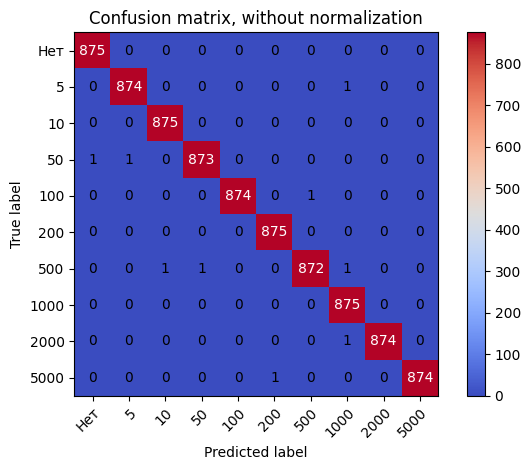

In [ ]:
train_generator.shuffle = False
Y_pred = model.predict_generator(train_generator, verbose = 1)
y_pred = np.argmax(Y_pred, axis = 1)
plot_confusion_matrix(train_generator.classes[train_generator.index_array], y_pred, np.array(['Нет', '5', '10', '50', '100', '200', '500', '1000', '2000', '5000']), False)
print(classification_report(train_generator.classes[train_generator.index_array], y_pred))

<ipython-input-12-78f43991f4d4>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(val_generator, verbose = 1)


79/79 [==============================] - 740s 9s/step
Confusion matrix, without normalization
[[250   0   0   0   0   0   0   0   0   0]
 [  0 250   0   0   0   0   0   0   0   0]
 [  0   0 250   0   0   0   0   0   0   0]
 [  0   2   0 246   0   1   0   0   0   1]
 [  0   3   0   0 241   2   1   3   0   0]
 [  0   0   0   0   0 250   0   0   0   0]
 [  0   0   3   0   0   1 244   1   0   1]
 [  0   0   0   0   0   0   0 250   0   0]
 [  0   0   0   0   0  12   0   0 238   0]
 [  0   0   0   0   0   0   0   0   0 250]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       250
           1       0.98      1.00      0.99       250
           2       0.99      1.00      0.99       250
           3       1.00      0.98      0.99       250
           4       1.00      0.96      0.98       250
           5       0.94      1.00      0.97       250
           6       1.00      0.98      0.99       250
           7       0.98      1.00      0.9

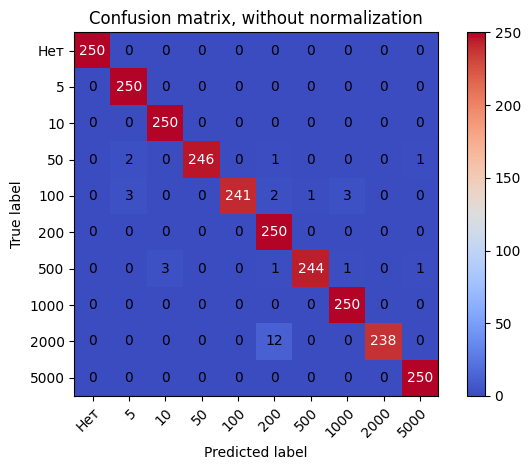

In [ ]:
val_generator.shuffle = False
Y_pred = model.predict_generator(val_generator, verbose = 1)
y_pred = np.argmax(Y_pred, axis = 1)
plot_confusion_matrix(val_generator.classes[val_generator.index_array], y_pred, np.array(['Нет', '5', '10', '50', '100', '200', '500', '1000', '2000', '5000']), False)
print(classification_report(val_generator.classes[val_generator.index_array], y_pred))

<ipython-input-13-e266863ee609>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(test_generator, verbose = 1)


40/40 [==============================] - 347s 9s/step
Confusion matrix, without normalization
[[125   0   0   0   0   0   0   0   0   0]
 [  0 123   0   0   0   2   0   0   0   0]
 [  0   0 123   0   0   1   1   0   0   0]
 [  1   0   0 124   0   0   0   0   0   0]
 [  0   0   0   0 125   0   0   0   0   0]
 [  0   0   0   0   0 125   0   0   0   0]
 [  0   0   3   1   0   1 120   0   0   0]
 [  0   0   0   0   0   0   0 125   0   0]
 [  0   0   0   0   0   7   0   0 117   1]
 [  0   0   0   0   0   0   0   0   0 125]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       125
           1       1.00      0.98      0.99       125
           2       0.98      0.98      0.98       125
           3       0.99      0.99      0.99       125
           4       1.00      1.00      1.00       125
           5       0.92      1.00      0.96       125
           6       0.99      0.96      0.98       125
           7       1.00      1.00      1.0

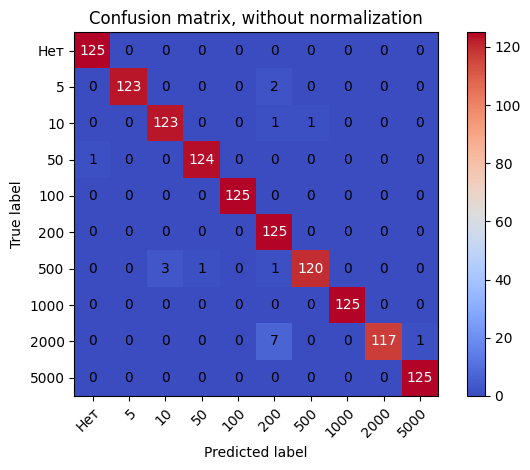

In [ ]:
test_generator.shuffle = False
Y_pred = model.predict_generator(test_generator, verbose = 1)
y_pred = np.argmax(Y_pred, axis = 1)
plot_confusion_matrix(test_generator.classes[test_generator.index_array], y_pred, np.array(['Нет', '5', '10', '50', '100', '200', '500', '1000', '2000', '5000']), False)
print(classification_report(test_generator.classes[test_generator.index_array], y_pred))

## Convert to TFLite

In [ ]:
saved_model_dir = path_train_cropped + '/save/fine_tuning'
tf.saved_model.save(model, saved_model_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

with open(saved_model_dir + '/model-8-MobNet-448.tflite', 'wb') as f:
  f.write(tflite_model)

In [ ]:
from google.colab import files

files.download(saved_model_dir + '/model-8-MobNet-448.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>